In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('CRH','V'), 
         ('CRH','WMT'), 
         ('CRH','XOM'), 
         ('TDG','V'), 
         ('TDG', 'WMT'),
         ('TDG', 'XOM'), 
         ('NEM','V'), 
         ('NEM', 'WMT'), 
         ('NEM','XOM')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.6s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.6s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

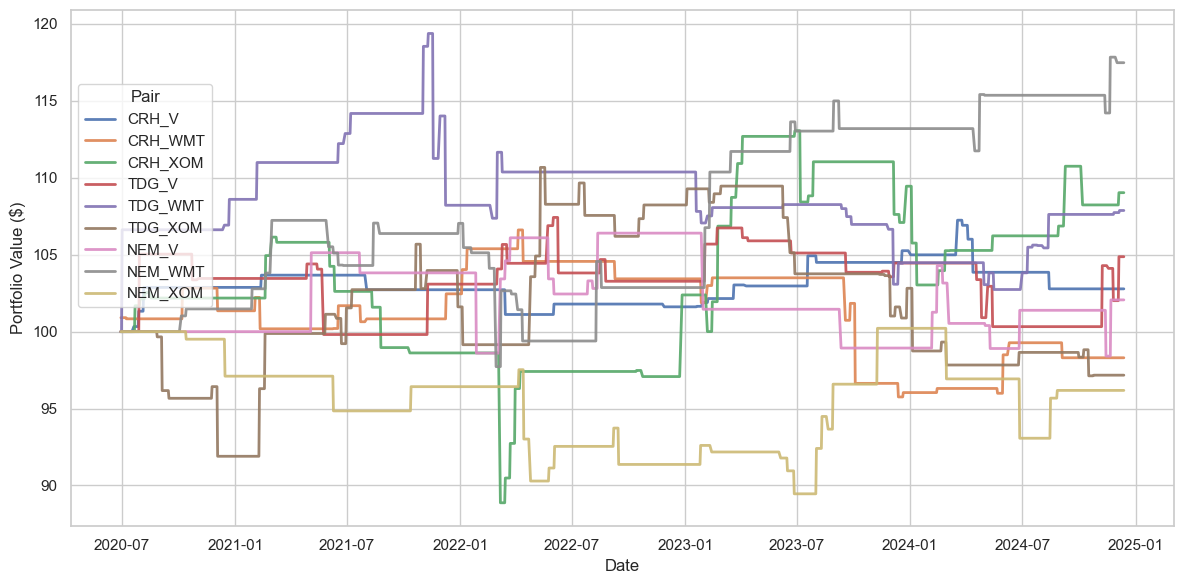

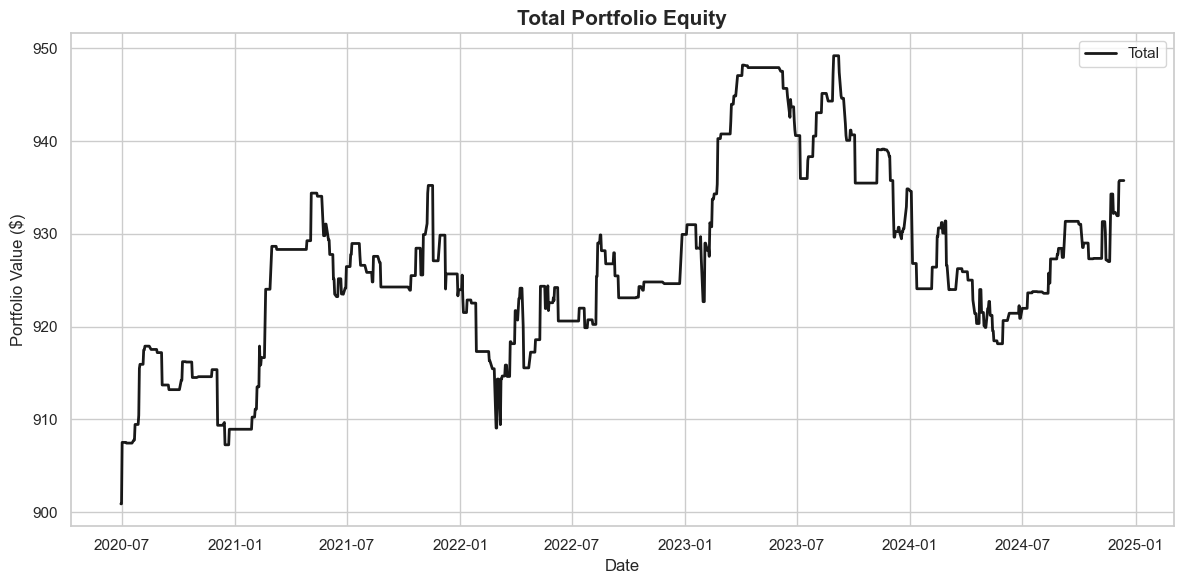

Summary
CRH_V: Final Value = $102.78, Total Return = 2.78%, Trades = 22
CRH_WMT: Final Value = $98.30, Total Return = -2.58%, Trades = 29
CRH_XOM: Final Value = $109.03, Total Return = 9.03%, Trades = 43
TDG_V: Final Value = $104.87, Total Return = 4.87%, Trades = 32
TDG_WMT: Final Value = $107.87, Total Return = 7.87%, Trades = 38
TDG_XOM: Final Value = $97.17, Total Return = -2.83%, Trades = 47
NEM_V: Final Value = $102.06, Total Return = 2.06%, Trades = 22
NEM_WMT: Final Value = $117.48, Total Return = 17.48%, Trades = 35
NEM_XOM: Final Value = $96.18, Total Return = -3.82%, Trades = 25

Total Portfolio Performance
Initial Portfolio Value: $900.91
Final Portfolio Value:   $935.75
Total Return:            3.87%

Sharpe Ratios
CRH_V: Sharpe Ratio = 0.28
CRH_WMT: Sharpe Ratio = -0.12
CRH_XOM: Sharpe Ratio = 0.28
TDG_V: Sharpe Ratio = 0.22
TDG_WMT: Sharpe Ratio = 0.29
TDG_XOM: Sharpe Ratio = -0.06
NEM_V: Sharpe Ratio = 0.10
NEM_WMT: Sharpe Ratio = 0.59
NEM_XOM: Sharpe Ratio = -0.13

Tot

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)